<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day4/NeuralForecast_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bitcoin Price Prediction using NeuralForecast
- Data Description
- Forecasting Models: NBEATS, NHITS, (Informer, Autoformer, FEDformer), PatchTST

In [ ]:
!pip install neuralforecast
!pip install yfinance
!pip install -U ipywidgets

import warnings
warnings.filterwarnings("ignore")

  Using cached neuralforecast-3.0.0-py3-none-any.whl.metadata (14 kB)
  Using cached coreforecast-0.0.16-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.7 kB)
  Using cached pytorch_lightning-2.5.1.post0-py3-none-any.whl.metadata (20 kB)
  Using cached ray-2.45.0-cp311-cp311-manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached optuna-4.3.0-py3-none-any.whl.metadata (17 kB)
  Using cached utilsforecast-0.2.12-py3-none-any.whl.metadata (7.6 kB)
  Using cached torchmetrics-1.7.1-py3-none-any.whl.metadata (21 kB)
  Using cached lightning_utilities-0.14.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached tensorboardX-2.6.2.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using

In [ ]:
# Data impots
import yfinance as yf
import pandas as pd
import numpy as np

# Neural Network Forecast imports
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, Informer, Autoformer, FEDformer, PatchTST

# Visualization Imports
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

pio.templates.default = "plotly_dark"

In [ ]:
# Target stock & columns for modeling
SYMBOL = "BTC"
columns = ['open', 'high', 'low', 'close', 'volume']

ticker = yf.Ticker(SYMBOL)

df = ticker.history(start="2024-01-01", end="2025-04-30").reset_index()

In [2]:
def plot_candlestick(df, name='Stock', rolling_avg=[20, 50, 100], fig_size=(1100, 700)):
    fig = go.Figure()

    # Candlestick chart
    fig.add_trace(go.Candlestick(
        x=df['Date'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        name=name
    ))

    # Rolling Averages
    for avg in rolling_avg:
        df[f'Rolling_{avg}'] = df['Close'].rolling(window=avg).mean()
        fig.add_trace(go.Scatter(
            x=df['Date'],
            y=df[f'Rolling_{avg}'],
            mode='lines',
            name=f'{avg}-Day Rolling Avg'
        ))

    # Layout customization
    fig.update_layout(
        title=f'{name} Candlestick Chart',
        xaxis_title='Date',
        yaxis_title='Price',
        width=fig_size[0],
        height=fig_size[1],
        xaxis_rangeslider_visible=False
    )

    fig.show()

In [ ]:
plot_candlestick(
    df,
    name=SYMBOL,
    rolling_avg=[20, 50, 200],
    fig_size=(1100, 700)
)

In [ ]:
df['Percent_Change'] = df['Close'].pct_change() * 100
#df['Percent_Change'].fillna(0, inplace=True)

In [ ]:
import plotly.subplots as sp

fig = sp.make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Percent Change {SYMBOL}",
                    f"Volume {SYMBOL}"),
    shared_xaxes=True,
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

fig.add_trace(go.Scatter(
    x=df.iloc[:, 0],  # 첫 번째 열을 x축으로 사용
    y=df['Percent_Change'],
    mode='lines',
    name='Percent Change',
    line=dict(color='orange')
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df.iloc[:, 0],  # 첫 번째 열을 x축으로 사용
    y=df['Volume'],
    name='Volume',
), row=2, col=1)

fig.update_layout(
    title="Stock Percent Change & Volume Analysis",
    xaxis_title="Date",
    yaxis_title="Percent Change (%)",
    xaxis_rangeslider_visible=False,
    width=1100,
    height=700,
    showlegend=True,
)

fig.show()

In [ ]:
df = ticker.history(start="2024-01-01", end="2025-04-30").reset_index()

df = df.copy()
df.rename(columns={df.columns[0]: 'ds'}, inplace=True)  # 첫 번째 열은 'ds'로 바꿈
df['y'] = df['Close']  # 타깃 열을 'y'로 설정

# NeuralForecast는 시계열별 고유 식별자 필요 ('unique_id')
df['unique_id'] = SYMBOL

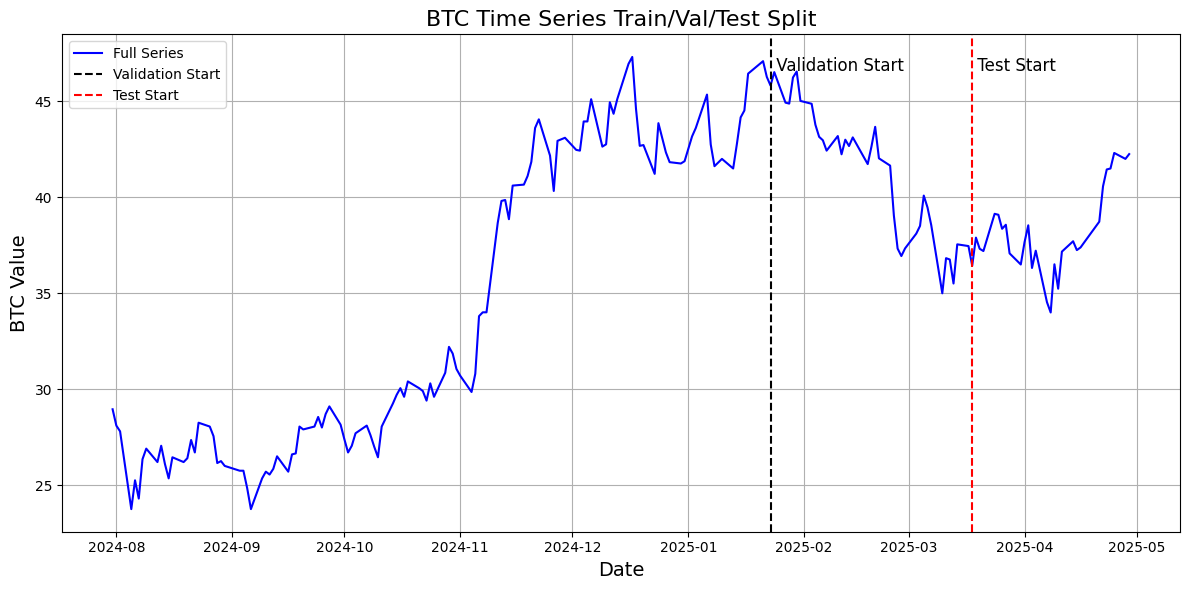

In [ ]:
# 전체 시계열 길이 기준 분할 비율 설정
n_time = len(df['ds'].unique())
val_size = int(n_time * 0.2)
test_size = 30
train_size = n_time - val_size - test_size

# 특정 종목 선택
u_id = SYMBOL
df_u = df[df['unique_id'] == u_id].copy().reset_index(drop=True)

# 분할 지점 정의
x_val = df_u['ds'].iloc[train_size]
x_test = df_u['ds'].iloc[train_size + val_size]

# 시각화용 데이터
x_plot = df_u['ds']
y_plot = df_u['y'].values

# 시각화
fig = plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, label='Full Series', color='blue')

# 분할 지점 시각화
plt.axvline(x_val, color='black', linestyle='--', label='Validation Start')
plt.axvline(x_test, color='red', linestyle='--', label='Test Start')

# 텍스트 표시
plt.text(x_val, max(y_plot), ' Validation Start', verticalalignment='top', fontsize=12)
plt.text(x_test, max(y_plot), ' Test Start', verticalalignment='top', fontsize=12)

# 라벨 및 스타일
plt.xlabel('Date', fontsize=14)
plt.ylabel(f'{u_id} Value', fontsize=14)
plt.title(f'{u_id} Time Series Train/Val/Test Split', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Y_train = df[df['ds'] < x_test].reset_index(drop=True)
Y_val = df[(df['ds'] >= x_val) & (df['ds'] < x_test)].reset_index(drop=True)
Y_test = df[df['ds'] >= x_test].reset_index(drop=True)

In [ ]:
len(df)

187

In [ ]:
# 예측 설정
horizon = 30         # 미래 30일 예측
input_size = 60      # 과거 60일 사용
freq = 'D'           # 일 단위 주기

# 모델 정의
models = [
    ('NBEATS', NBEATS(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    ('NHITS', NHITS(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('Informer', Informer(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('Autoformer', Autoformer(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('FEDformer', FEDformer(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    ('PatchTST', PatchTST(input_size=input_size, h=horizon, max_steps=100, batch_size=64, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
]

# 개별 모델 학습 및 결과 저장
forecasts = []
for name, model in models:
    print(f"\n🔧 Training model: {name}")
    nf = NeuralForecast(models=[model], freq=freq)
    nf.fit(df=Y_train, val_size=len(Y_val))
    pred = nf.predict()
    forecasts.append(pred.rename(columns={name: name}))

In [ ]:
Y_hat = forecasts[0]

for forecast in forecasts[1:]:
    Y_hat = Y_hat.merge(forecast, on='ds', how='outer')

Y_hat = Y_hat[['ds', 'NBEATS', 'NHITS', 'PatchTST']]
Y_hat['ds'] = list(Y_test['ds'])
Y_hat

,ds,NBEATS,NHITS,PatchTST
0,2025-03-18 00:00:00-04:00,37.530670,37.000877,39.610771
1,2025-03-19 00:00:00-04:00,37.707214,38.191906,38.242973
2,2025-03-20 00:00:00-04:00,41.192226,41.764641,38.744946
3,2025-03-21 00:00:00-04:00,42.403522,43.364586,44.778019
4,2025-03-24 00:00:00-04:00,41.583183,43.950146,42.081833
5,2025-03-25 00:00:00-04:00,39.992756,44.801075,43.825569
6,2025-03-26 00:00:00-04:00,45.761986,52.394291,39.710537
7,2025-03-27 00:00:00-04:00,53.212170,56.460888,38.336689
8,2025-03-28 00:00:00-04:00,52.847218,57.985878,36.639587
9,2025-03-31 00:00:00-04:00,54.310318,58.043823,36.500957


In [ ]:
# 예측 결과와 실제 데이터를 결합하여 출력
#display(pd.concat([Y_test['y'], Y_hat], axis=1)[['ds', 'NBEATS', 'NHITS', 'y']])

# Traces for each line (train, test, predictions)
trace_train = go.Scatter(x=Y_train['ds'], y=Y_train['y'], line=dict(color='blue'), name='Close Train')
trace_test = go.Scatter(x=Y_test['ds'], y=Y_test['y'], mode='lines', line=dict(color='red'), name='Close Test')


model_traces = []
color_map = {
    'NBEATS': 'cyan',
    'NHITS': 'green',
    # 'Informer': 'magenta',
    # 'Autoformer': 'purple',
    # 'FEDformer': 'brown',
    'PatchTST': 'orange'
}

for col in Y_hat.columns:
    if col not in ['ds']:
        color = color_map.get(col, None)
        trace = go.Scatter(x=Y_hat['ds'], y=Y_hat[col], mode='lines',
                           line=dict(color=color) if color else None,
                           name=f'{col} Pred')
        model_traces.append(trace)

layout = go.Layout(
    title='Prediction Comparison',
    xaxis=dict(title='Date'),
    yaxis=dict(title=f'{u_id} Value'),
    showlegend=True,
    legend=dict(x=0.02, y=0.98)
)

# x축 자동 범위 설정 (test 구간 기준)
start_date = Y_train['ds'].min()
end_date = Y_test['ds'].max()

fig = go.Figure(data=[trace_train, trace_test] + model_traces, layout=layout)
fig.update_xaxes(range=[start_date, end_date])
fig.show()


### References
- https://nixtlaverse.nixtla.io/neuralforecast/docs/getting-started/introduction.html
- https://nixtlaverse.nixtla.io/neuralforecast/docs/tutorials/longhorizon_transformers.html
- https://www.kaggle.com/code/guslovesmath/amazing-nvda-forecasting-neuralforecast